In [ ]:
!nvidia-smi

Thu Jul 23 05:54:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics imagehash -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 28.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q -o "/content/drive/MyDrive/Palm-anemia.zip" -d /content/dataset_telapak
print("Dataset beres diekstrak dan siap dilatih!")

Dataset beres diekstrak dan siap dilatih!


In [ ]:
!find /content/dataset_telapak -maxdepth 3 -type d

/content/dataset_telapak
/content/dataset_telapak/Palm-anemia
/content/dataset_telapak/Palm-anemia/normal
/content/dataset_telapak/Palm-anemia/anemia


In [ ]:
import os, shutil, random
import imagehash
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

src_root = "/content/dataset_telapak/Palm-anemia"
dst_root = "/content/dataset_telapak_split"
split_ratio = 0.8
HASH_THRESHOLD = 5  # makin kecil = makin ketat definisi "mirip". 5 itu titik awal yang wajar, bisa dicoba 3-8.

def compute_hashes(folder):
    """Hitung perceptual hash tiap gambar di folder."""
    hashes = {}
    for f in os.listdir(folder):
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        try:
            h = imagehash.phash(Image.open(os.path.join(folder, f)))
            hashes[f] = h
        except Exception as e:
            print(f"Gagal baca {f}: {e}")
    return hashes

def group_similar(hashes, threshold=HASH_THRESHOLD):
    """
    Union-Find sederhana: kelompokkan file yang hash-nya berdekatan
    jadi satu 'group'. Group ini yang nanti displit bareng-bareng,
    bukan file individual.
    """
    files = list(hashes.keys())
    parent = {f: f for f in files}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        px, py = find(x), find(y)
        if px != py:
            parent[px] = py

    n = len(files)
    for i in range(n):
        for j in range(i + 1, n):
            if hashes[files[i]] - hashes[files[j]] <= threshold:
                union(files[i], files[j])

    groups = {}
    for f in files:
        root = find(f)
        groups.setdefault(root, []).append(f)

    return list(groups.values())  # list of list of filenames

print("\n=== Menghitung hash & mengelompokkan gambar mirip ===")
for cls in ["anemia", "normal"]:
    src_cls_dir = os.path.join(src_root, cls)
    hashes = compute_hashes(src_cls_dir)
    groups = group_similar(hashes)

    n_dupe_groups = sum(1 for g in groups if len(g) > 1)
    print(f"Kelas '{cls}': total_file={len(hashes)}, total_group={len(groups)}, "
          f"group_berisi_>1_gambar_mirip={n_dupe_groups}")

    # Split berbasis GROUP, bukan file individual
    random.shuffle(groups)
    n_train_groups = int(len(groups) * split_ratio)
    train_groups = groups[:n_train_groups]
    val_groups = groups[n_train_groups:]

    train_files = [f for g in train_groups for f in g]
    val_files = [f for g in val_groups for f in g]

    for split, flist in [("train", train_files), ("val", val_files)]:
        out_dir = os.path.join(dst_root, split, cls)
        os.makedirs(out_dir, exist_ok=True)
        for f in flist:
            shutil.copy(os.path.join(src_cls_dir, f), os.path.join(out_dir, f))

    print(f"  -> train={len(train_files)} gambar, val={len(val_files)} gambar")

print("\nSplit anti-leakage selesai ->", dst_root)


=== Menghitung hash & mengelompokkan gambar mirip ===
Kelas 'anemia': total_file=2562, total_group=1180, group_berisi_>1_gambar_mirip=821
  -> train=2044 gambar, val=518 gambar
Kelas 'normal': total_file=1698, total_group=865, group_berisi_>1_gambar_mirip=557
  -> train=1369 gambar, val=329 gambar

Split anti-leakage selesai -> /content/dataset_telapak_split


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

DATA_DIR = "/content/dataset_telapak_split"

results = model.train(
    data=DATA_DIR,
    epochs=50,
    imgsz=512,
    plots=True,
    degrees=15.0,
    fliplr=0.5,
    hsv_s=0.2,
    hsv_v=0.2,
    scale=0.1
)

model_telapak = YOLO(f'{results.save_dir}/weights/best.pt')
print("Urutan kelas model telapak:", model_telapak.names)

model_telapak.export(format='tflite', imgsz=512)
print("Export selesai.")

shutil.make_archive('Model_Palepal_Telapak_CLS', 'zip', str(results.save_dir))
print("Selesai! File 'Model_Palepal_Telapak_CLS.zip' siap didownload.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_telapak_split, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, 

/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1745: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.1...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:07) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:07) [ DONE] LiteRT-Torch Convert (+00:07)

(00:00) [START] Write Model to /content/runs/classify/train/weights/best.tflite

(00:00) [ DONE] Write Model to /content/runs/classify/train/weights/best.tflite (+00:00)

LiteRT: export success ✅ 16.7s, saved as '/content/runs/classify/train/weights/best.tflite' (5.5 MB)

Export complete (16.9s)
Results saved to /content/runs/classify/train/weights/best.tflite
Predict:         yolo predict task=classify model=/content/runs/classify/train/weights/best.tflite imgsz=512 
Validate:        yolo val task=classify model=/content/runs/classify/train/weights/best.tflite imgsz=512 data=/content/dataset_telapak_split  
Visualize:       https://netron.app
Export selesai.
Selesai! File 'Model_Palepal_Telapak_CLS.zip' siap didownload.


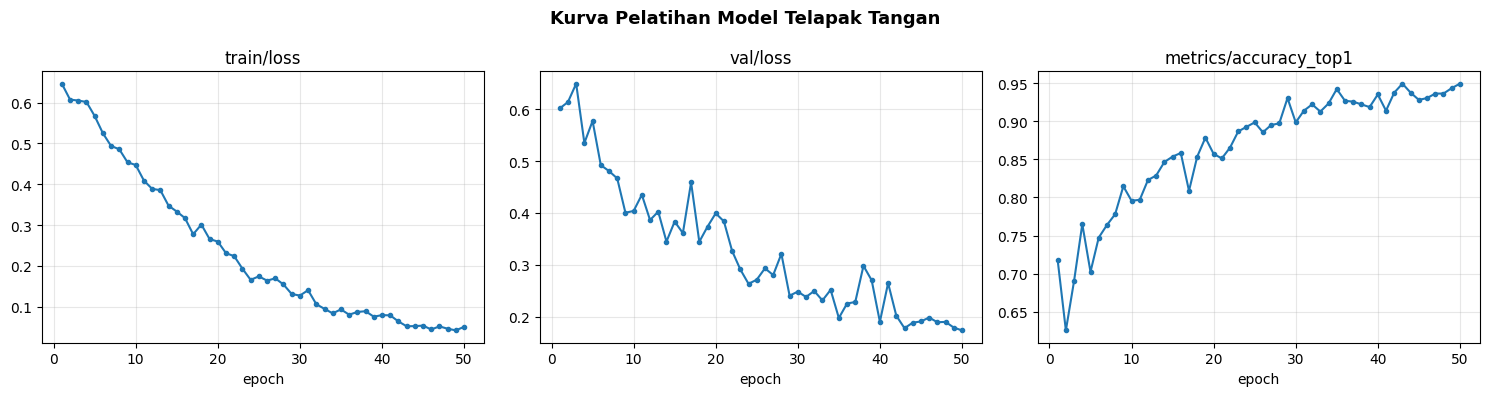


Grafik kurva telapak (tanpa top-5) tersimpan di: /content/kurva_telapak_tanpa_top5.png
Download file ini untuk diupload ke chat.


In [ ]:
csv_path = os.path.join(str(results.save_dir), "results.csv")
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['epoch'], df['train/loss'], marker='o', markersize=3, color='#1f77b4')
axes[0].set_title('train/loss')
axes[0].set_xlabel('epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(df['epoch'], df['val/loss'], marker='o', markersize=3, color='#1f77b4')
axes[1].set_title('val/loss')
axes[1].set_xlabel('epoch')
axes[1].grid(alpha=0.3)

axes[2].plot(df['epoch'], df['metrics/accuracy_top1'], marker='o', markersize=3, color='#1f77b4')
axes[2].set_title('metrics/accuracy_top1')
axes[2].set_xlabel('epoch')
axes[2].grid(alpha=0.3)

fig.suptitle("Kurva Pelatihan Model Telapak Tangan", fontsize=13, fontweight='bold')
plt.tight_layout()

out_path = "/content/kurva_telapak_tanpa_top5.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGrafik kurva telapak (tanpa top-5) tersimpan di: {out_path}")
print("Download file ini untuk diupload ke chat.")